# Artificial Intelligence and Society 2024/2025
### Individual Assignment 4: Missing Data

**Author:** Adriano Machado (FEUP/FCUP)

## Introduction

This assignment has the goal of investigating the impact of different missing data mechanisms (MCAR, MAR, MNAR) on the performance of classification algorithms and explores the effectiveness of various missing data handling strategies.

For this, we'll use three datasets without missing values and artificially introduce missing values in them. We'll then select among several approaches to handle missing data (e.g., classifying with missing values, performing data imputation) and compare the obtained classification performance across different approaches.

## Datasets

- [Diabetes](https://scikit-learn.org/1.5/modules/generated/sklearn.datasets.load_diabetes.html) - The Diabetes Dataset consists of ten baseline variables: age, sex, body mass index, average blood pressure, and six blood serum measurements. These were obtained for each of 442 diabetes patients. The target is a quantitative measure of disease progression one year after baseline.



In [1]:
from sklearn.datasets import load_diabetes, load_wine, load_breast_cancer
import pandas as pd

load_diabetes_data = load_diabetes()
df_diabetes = pd.DataFrame(load_diabetes_data.data, columns=load_diabetes_data.feature_names)


X_diabetes = df_diabetes
y_diabetes = load_diabetes_data.target
df_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [2]:
df_diabetes.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


All of these variables are numerical and don't have missing values, thus we can skip the data preprocessing step.

- [Wine Recognition](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) - The UCI Wine Recognition Dataset consists of 13 quantitative measures of wine and a 3-class target value representing the type of wine. 

In [3]:
load_wine_data = load_wine()
df_wine = pd.DataFrame(load_wine_data.data, columns=load_wine_data.feature_names)

X_wine = df_wine
y_wine = load_wine_data.target

df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


- [Abalone](https://archive.ics.uci.edu/dataset/1/abalone) - Predicting the age of abalone from physical measurements.  

In [4]:
abalone_path = 'datasets/abalone/abalone.csv'
abalone_names = ['sex', 'length', 'diameter', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight', 'rings']
df_abalone = pd.read_csv(abalone_path, names=abalone_names)

print("\nAbalone Dataset Describe:")
df_abalone.describe().T

df_abalone.head()


Abalone Dataset Describe:


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


Let's use one-hot encoding to transform the sex variable. 

In [5]:
df_abalone = pd.get_dummies(df_abalone, columns=['sex'])
df_abalone.head()

,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings,sex_F,sex_I,sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,False,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,False,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,True,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,False,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,False,True,False


## Missing Data Mechanisms

Missing data mechanisms describe how the probability of a missing values related to the data, if at all


*   **Missing Completely At Random (MCAR):** Missingness is unrelated to *any* observed or unobserved data. The absence of data occurs randomly, without any discernible pattern 
    *   Example: A survey respondent unintentionally skips a question
    <!-- *   Is easily handled with simple methods like listwise deletion or mean imputation; -->

*   **Missing At Random (MAR):** The missingness can be explained by some observed features in the dataset. Although the data is missing systematically, it is still considered random because the missingness is not related to the unobserved values.
    *   Example: In a tobacco study, younger participants might report their values less often (regardless of how much they smoke), leading to systematic missingness for age-related reasons
    *   Requires more sophisticated handling techniques like multiple imputation or maximum likelihood estimation;

*   **Missing Not At Random (MNAR):** MNAR occurs when the missingness itself is related to the unobserved data. In this case, the missing data is not random and is associated with specific reasons or patterns.
    *   Example: Referring to the tobacco study example, participants who smoke the most might intentionally withhold their smoking habits, leading to systematic missingness related to the missing data.
    *   Is the most challenging to handle, as the reasons for missingness are not captured within the observed data;

In order to simulate these mechanisms in our datasets, we'll use the [`mdatagen library`](https://arthurmangussi.github.io/pymdatagen/).

In [6]:
from mdatagen.univariate.uMCAR import uMCAR
from mdatagen.univariate.uMAR import uMAR
from mdatagen.univariate.uMNAR import uMNAR
from mdatagen.plots.plot import PlotMissingData
from mdatagen.multivariate.mMCAR import mMCAR
from mdatagen.multivariate.mMAR import mMAR
from mdatagen.multivariate.mMNAR import mMNAR
import matplotlib.pyplot as plt
import numpy as np

generator = uMCAR(X=df_diabetes.copy(), y=y_diabetes, missing_rate=20, x_miss="bp")
df_diabetes_mcar_multi_random = generator.random()


generator = uMAR(X=df_diabetes.copy(), y=y_diabetes, missing_rate=20, x_miss="bp")
df_diabetes_mar_multi_random = generator.lowest()

generator = uMNAR(X=df_diabetes.copy(), y=y_diabetes, threshold=0)
df_diabetes_mnar_multi_random = generator.run()

In [7]:
from missingno import missingno as msno

def visualize_missing_data_missingno(data_missing, data_original, mechanism_name, dataset_name, visualization_type="matrix", col_missing=None, cols_scatter=None, ax=None):
    """
    Visualizes missing data patterns using the missingno module and matplotlib for scatterplot.

    Args:
        data_missing (pd.DataFrame): Dataset with missing values.
        data_original (pd.DataFrame): Original complete dataset. # Added data_original as it might be useful for scatterplot context
        mechanism_name (str): Name of the missing data mechanism (for title).
        dataset_name (str): Name of the dataset (for title).
        visualization_type (str, optional): Type of visualization
            ('matrix', 'bar', 'dendrogram', 'heatmap', 'scatterplot').
            Defaults to "matrix".
        col_missing (str, optional): Column name for visualizations (not directly used by missingno in this example, but kept for consistency). Defaults to None.
        cols_scatter (tuple, optional): Column names (x, y) for 'scatterplot'. Defaults to None.
        ax (matplotlib.axes._axes.Axes, optional):  Axes object to plot on. Defaults to None, which creates a new figure and axes.

    Returns:
        matplotlib.axes._axes.Axes: The matplotlib Axes object after visualization.
    """

    visualization_types_missingno = ["matrix", "bar", "dendrogram", "heatmap"]
    visualization_types_all = visualization_types_missingno + ["scatterplot"]


    if visualization_type not in visualization_types_all:
        raise ValueError(f"Invalid visualization_type: {visualization_type}. Choose from {', '.join(visualization_types_all)}.")

    if visualization_type == "scatterplot":
        if cols_scatter is None:
            raise ValueError(f"For 'scatterplot', cols_scatter must be specified as a tuple (col_x, col_y).")
        return _geom_miss_plot_missingno(data_missing, cols_scatter, mechanism_name, dataset_name, ax=ax) 
    elif visualization_type in visualization_types_missingno:
        if visualization_type == "matrix":
            ax_msno = msno.matrix(data_missing, ax=ax, sparkline=False)
        elif visualization_type == "bar":
            ax_msno = msno.bar(data_missing, ax=ax)
        elif visualization_type == "dendrogram":
            ax_msno = msno.dendrogram(data_missing, ax=ax)
        elif visualization_type == "heatmap":
            ax_msno = msno.heatmap(data_missing, ax=ax)

        if ax_msno is not None: 
            ax_msno.set_title(f"{visualization_type.capitalize()} Plot - {mechanism_name} - {dataset_name}")
        return ax_msno
    else:
        raise ValueError(f"Invalid visualization_type: {visualization_type}. Choose from {', '.join(visualization_types_missingno)} or 'scatterplot'.")


def _geom_miss_plot_missingno(data_missing, cols:tuple[str, str], mechanism_name, dataset_name, threshold:tuple[float,float,float]=(0.5, 0.8, 0.9), ax=None):
    col_x, col_y = cols
    df_aux = pd.DataFrame(columns=[col_x,col_y])
    df_aux[[col_x, col_y]] = data_missing[[col_x, col_y]].copy()
    df_aux['Indicator'] = df_aux[[col_x, col_y]].isna().any(axis=1).map({True:"Missing", False: "Not Missing"})

    min_values = df_aux[[col_x, col_y]].min()
    for col in [col_x, col_y]:
        if df_aux[col].isna().any():
            min_val = min_values[col]
            offset_range = (threshold[0] * min_val, threshold[1] * min_val)
            df_aux[col] = df_aux[col].apply(lambda value: np.random.uniform(offset_range[0], offset_range[1]) if pd.isna(value) else value)


    if ax is None:
        fig, ax = plt.subplots() 

    missing_data = df_aux[df_aux['Indicator'] == 'Missing']
    not_missing_data = df_aux[df_aux['Indicator'] == 'Not Missing']

    ax.scatter(not_missing_data[col_x], not_missing_data[col_y], label='Not Missing', color='blue', alpha=0.7) 
    ax.scatter(missing_data[col_x], missing_data[col_y], label='Missing', color='red', alpha=0.7)


    ax.set_xlabel(col_x)
    ax.set_ylabel(col_y)
    ax.legend()
    ax.axvline(x=threshold[2] * min_values[col_x], color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.axhline(y=threshold[2] * min_values[col_y], color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.set_title(f"Scatterplot - {mechanism_name} - {dataset_name}")

    return ax

def plot_mechanisms_missingno(data_original, mechanisms_df_dict, visualization_type, cols_scatter=None, x_obs_param=None):
    fig, axes = plt.subplots(len(visualization_type), len(mechanisms_df_dict), figsize=(18, 10))
    for i, visualization_type in enumerate(visualization_type):
        for j, mechanism in enumerate(mechanisms_df_dict.keys()):
            df_missing = mechanisms_df_dict[mechanism]
            ax = axes[i, j]
            visualize_missing_data_missingno(
                data_missing=df_missing,
                data_original=data_original,
                mechanism_name=mechanism.upper(),
                dataset_name="Diabetes",
                visualization_type=visualization_type,
                cols_scatter=cols_scatter,
                ax=ax
            )

            if i == 0:
                ax.set_title(f"Mechanism: {mechanism.upper()}")

            if j == 0:
                ax.set_ylabel(f"Visualization: {visualization_type.capitalize()}", rotation=90, labelpad=20)

    plt.tight_layout()
    plt.show()

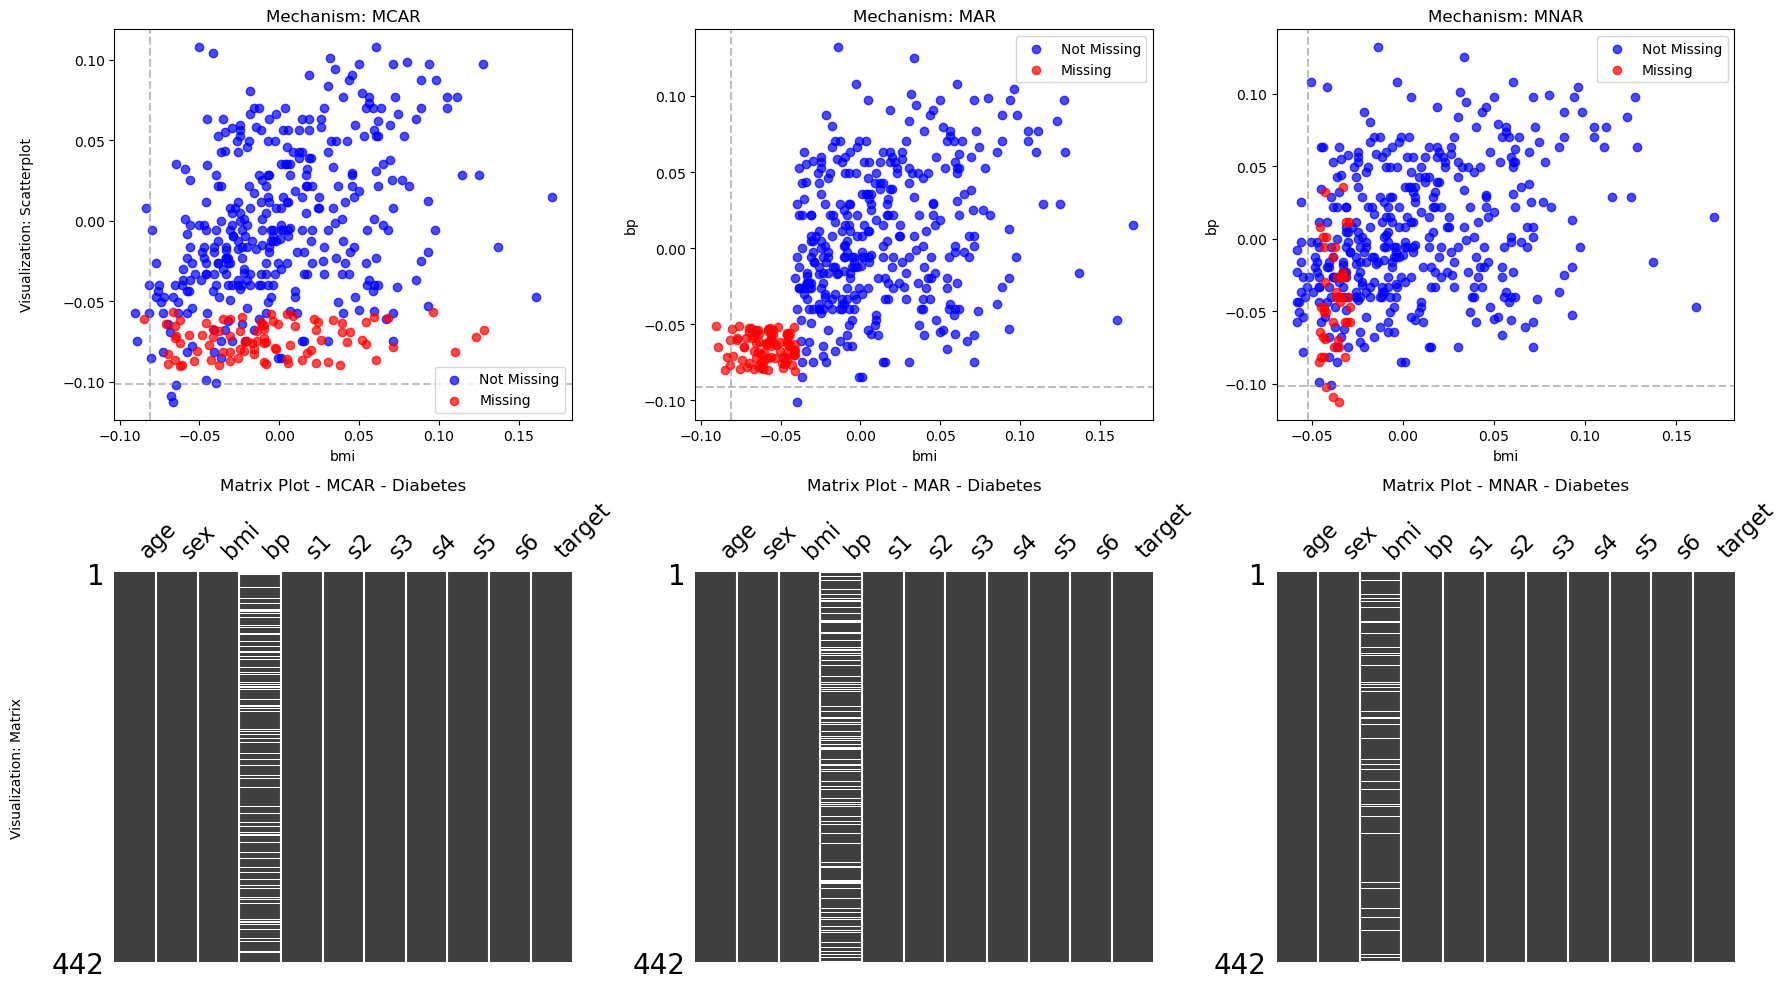

In [8]:
plot_mechanisms_missingno(df_diabetes, 
                          mechanisms_df_dict={"MCAR": df_diabetes_mcar_multi_random, "MAR": df_diabetes_mar_multi_random, "MNAR": df_diabetes_mnar_multi_random}, 
                          visualization_type=["scatterplot", "matrix"], 
                          cols_scatter=('bmi', 'bp'))

## Approaches to Handle Missing Data

<div align="center">
  <img src="handling_missing_data.png" width="1000" >
</div>



There's four main ways to handle missing data:

*   **Case Deletion: In theory it should only be applied with MCAR** 

*   **Missing Data Imputation:**
    *   **Statistical Imputation: If the mechanism is not MCAR, the imputation might be biased.**
    *   **Machine Learning Imputation** 

*   **Maximum Likelihood:** 

Let's start implementing these approaches and evaluate their performance.

### 1. Case Deletion - Listwise Deletion

Listwise deletion involves removing any rows with missing values. We will apply this to our datasets with MCAR, MAR, and MNAR mechanisms.


In [9]:
def listwise_deletion(df_missing):
    df_deleted = df_missing.dropna()
    return df_deleted

### 2. Statistical Imputation - Mean Imputation

Now, let's implement mean imputation, where missing values are replaced by the mean of the feature.



In [10]:
def mean_imputation(df_missing):
    df_imputed = df_missing.fillna(df_missing.mean())
    return df_imputed

### 3. Machine Learning Imputation - KNN Imputation
Finally, let's use KNN imputation, a simple machine learning based imputation technique.



In [11]:
from sklearn.impute import KNNImputer

def knn_imputation(df_missing, n_neighbors=5):
    imputer = KNNImputer(n_neighbors=n_neighbors)
    df_imputed_values = imputer.fit_transform(df_missing)
    df_imputed = pd.DataFrame(df_imputed_values, columns=df_missing.columns, index=df_missing.index)
    return df_imputed

### 4. MICE - Multiple Imputation by Chained Equations

In [12]:
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer

def mice_imputation(df_missing, max_iter=10):
    imputer = IterativeImputer(max_iter=max_iter, random_state=0) 
    df_imputed_values = imputer.fit_transform(df_missing)
    df_imputed = pd.DataFrame(df_imputed_values, columns=df_missing.columns, index=df_missing.index) 
    return df_imputed

## Comparison of Results

Let's summarize the results to compare the performance of different methods under different missing data mechanisms.